In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils
from sklearn.preprocessing import LabelEncoder

In [ ]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [ ]:
from snntorch import spikegen

class CustomDatasetSpike(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=4, gain=1):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.gain = gain

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.rate(img, num_steps=self.num_steps, gain=self.gain)
            return img, label


In [ ]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")

In [ ]:
val_df.head()

In [ ]:
# shuffle val and test
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = CustomDatasetSpike(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDatasetSpike(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [ ]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [ ]:
class BasicSNN(nn.Module):
    def __init__(self, beta=1, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=4)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=2, stride=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)


        # flattened_size = 32 * (32 // 4) * (32 // 4)

        self.fc1 = nn.Linear(32, self.num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.spk1 = None
        self.spk2 = None


    def forward(self, x):
        # x shape: [batch_size, num_steps, C, H, W]
        x = x.permute(1, 0, 2, 3, 4)  # New shape: [num_steps, batch_size, C, H, W]
        
        mem1 = self.lif1.reset_mem()
        mem2 = self.lif2.reset_mem()
        mem3 = self.lif3.reset_mem()

        spk_rec = []
        mem_rec = []

        spk1_rec = []
        spk2_rec = []

        for step in range(self.num_steps):
            x_step = x[step]  # [batch_size, C, H, W] for current timestep

            # Layer 1
            cur1 = self.conv1(x_step)
            cur1 = F.max_pool2d(cur1, 2)  # Optional pooling
            spike1, mem1 = self.lif1(cur1, mem1)

            # Layer 2
            cur2 = self.conv2(spike1)
            cur2 = F.max_pool2d(cur2, 2)  # Optional pooling
            spike2, mem2 = self.lif2(cur2, mem2)

            # print(spike2.shape)
            # print(spike2.flatten(1).shape)

            # Classifier
            cur3 = self.fc1(spike2.flatten(1))
            spike3, mem3 = self.lif3(cur3, mem3)


            spk1_rec.append(spike1)
            spk2_rec.append(spike2)

            spk_rec.append(spike3)
            mem_rec.append(mem3)

        self.spk1 = torch.stack(spk1_rec, dim=0)
        self.spk2 = torch.stack(spk2_rec, dim=0)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [ ]:
dummy = torch.randn(1, 4, 1, 32, 32)
model = BasicSNN()
out, _ = model(dummy)

model.spk1.shape, model.spk2.shape, out.shape

For `torch.stack`, the `dim` affects the output of the function.
1. `dim=1` -> shape: `[batch_size, time_step, output_neurons]`
2. `dim=0` -> shape: `[time_step, batch_size, output_neurons]`
3. `dim=-1` -> shape: `[batch_size, output_neurons, time_step]`


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_class_metrics(y_true, y_pred):

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'benign': {
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [116]:
def train_model(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=4).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay if weight_decay else 0,
                                 betas=(0.9, 0.999))
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=num_epochs // 5, T_mult=1, eta_min=1e-6, last_epoch=-1)

    # Initialize metrics tracking dictionary
    metrics = {
        'train': {
            'loss': [],           # Per batch loss
            'avg_loss': [],       # Per epoch average loss
            'acc': [],            # Per epoch accuracy
            'f1': [],             # Per epoch overall F1
            'class_metrics': [],  # Per epoch class-specific metrics
        },
        'val': {
            'loss': [],
            'avg_loss': [],
            'acc': [],
            'f1': [],
            'class_metrics': [],
        },
        # Spike statistics
        'spike_stats': {
            'train': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'val': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'firing_rate_stability': [], # General stability metric
        }
    }

    best_val_f1 = -1.0  # Track best F1 score instead of loss
    best_model_state = None
    neuron_cache = {'layer1': None, 'layer2': None, 'output': None}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # --- TRAINING PHASE ---
        model.train()
        # Per-epoch tracking
        epoch_data = {
            'train_loss': 0,
            'train_correct': 0.0,
            'train_total': 0,
            'spike_count': 0,
            'active_neurons': 0,
            'total_neurons': 0,
            'total_possible': 0,
            'train_preds': [],
            'train_targets': [],
            'sum_mem': 0.0,
            'sum_sq_mem': 0.0,
            'total_mem_samples': 0,
            'proximity_sum': 0.0,
            'proximity_sq_sum': 0.0,
            'proximity_samples': 0,
        }

        for data, targets in tqdm(train_dataloader, desc="Training"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)

            # Forward pass
            spk_rec, mem_rec = model(data)

            # Calculate neuron counts once
            if neuron_cache['layer1'] is None:
                with torch.no_grad():
                    neuron_cache['layer1'] = model.spk1[0, 0].numel()
                    neuron_cache['layer2'] = model.spk2[0, 0].numel()
                    neuron_cache['output'] = spk_rec.size(-1)

            # Loss calculation
            loss = loss_fn(spk_rec, targets)
            epoch_data['train_loss'] += loss.item()
            metrics['train']['loss'].append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- METRICS CALCULATION ---
            with torch.no_grad():
                # Accuracy
                acc = SF.accuracy_rate(spk_rec, targets)
                epoch_data['train_correct'] += acc * data.size(0)
                epoch_data['train_total'] += data.size(0)

                # Predictions for F1
                preds = torch.argmax(spk_rec.sum(dim=0), dim=1)
                epoch_data['train_preds'].append(preds.cpu())
                epoch_data['train_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike_count = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                epoch_data['spike_count'] += batch_spike_count

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                total_batch_neurons = (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps
                epoch_data['total_neurons'] += total_batch_neurons

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_data['active_neurons'] += active1 + active2 + active3
                epoch_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane statistics
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    epoch_data['sum_mem'] += mem_tensor.sum().item()
                    epoch_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    epoch_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    epoch_data['proximity_sum'] += proximity.sum().item()
                    epoch_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    epoch_data['proximity_samples'] += proximity.numel()

        # --- EPOCH TRAINING METRICS ---
        avg_train_loss = epoch_data['train_loss'] / len(train_dataloader)
        metrics['train']['avg_loss'].append(avg_train_loss)
        
        train_acc = epoch_data['train_correct'] / epoch_data['train_total'] if epoch_data['train_total'] > 0 else 0.0
        metrics['train']['acc'].append(train_acc)

        # Calculate F1 score and class-specific metrics
        train_preds = torch.cat(epoch_data['train_preds']).numpy() if len(epoch_data['train_preds']) > 0 else np.array([])
        train_targets = torch.cat(epoch_data['train_targets']).numpy() if len(epoch_data['train_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        train_f1 = f1_score(train_targets, train_preds, average='weighted') if len(train_preds) > 0 else 0.0
        metrics['train']['f1'].append(train_f1)
        
        # Calculate class-specific metrics
        if len(train_preds) > 0:
            train_class_metrics = calculate_class_metrics(train_targets, train_preds)
            metrics['train']['class_metrics'].append(train_class_metrics)
        else:
            train_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['train']['class_metrics'].append(train_class_metrics)

        # Spike metrics
        avg_spikes_per_neuron = epoch_data['spike_count'] / epoch_data['total_neurons'] if epoch_data['total_neurons'] > 0 else 0.0
        active_percent = (epoch_data['active_neurons'] / epoch_data['total_possible']) * 100 if epoch_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['train']['avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        metrics['spike_stats']['train']['spike_rate_hz'].append(avg_spikes_per_neuron * (1000 / dt_ms))
        metrics['spike_stats']['train']['spike_count'].append(epoch_data['spike_count'])
        metrics['spike_stats']['train']['active_neurons_percent'].append(active_percent)

        # Membrane metrics
        if epoch_data['total_mem_samples'] > 0:
            avg_mem = epoch_data['sum_mem'] / epoch_data['total_mem_samples']
            std_mem = np.sqrt((epoch_data['sum_sq_mem'] / epoch_data['total_mem_samples']) - avg_mem**2)
        else:
            avg_mem = std_mem = 0.0
        metrics['spike_stats']['train']['membrane_potential_avg'].append(avg_mem)
        metrics['spike_stats']['train']['membrane_potential_std'].append(std_mem)

        # Threshold proximity
        if epoch_data['proximity_samples'] > 0:
            avg_prox = epoch_data['proximity_sum'] / epoch_data['proximity_samples']
            std_prox = np.sqrt((epoch_data['proximity_sq_sum'] / epoch_data['proximity_samples']) - avg_prox**2)
        else:
            avg_prox = std_prox = 0.0
        metrics['spike_stats']['train']['threshold_proximity_avg'].append(avg_prox)
        metrics['spike_stats']['train']['threshold_proximity_std'].append(std_prox)

        print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Benign - P: {train_class_metrics['benign']['precision']:.4f}, R: {train_class_metrics['benign']['recall']:.4f}, F1: {train_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {train_class_metrics['malicious']['precision']:.4f}, R: {train_class_metrics['malicious']['recall']:.4f}, F1: {train_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {avg_spikes_per_neuron:.4f} ({avg_spikes_per_neuron*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: {active_percent:.1f}%")
        print("-" * 50)

        # --- VALIDATION PHASE ---
        with torch.no_grad():
            model.eval()
            # Per-epoch validation tracking
            val_data = {
                'val_loss': 0,
                'val_correct': 0.0,
                'val_total': 0,
                'spike_count': 0,
                'total_neurons': 0,
                'active_neurons': 0,
                'total_possible': 0,
                'val_preds': [],
                'val_targets': [],
                'sum_mem': 0.0,
                'sum_sq_mem': 0.0,
                'total_mem_samples': 0,
                'proximity_sum': 0.0,
                'proximity_sq_sum': 0.0,
                'proximity_samples': 0,
            }
            
            for data, targets in tqdm(val_dataloader, desc="Validation"):
                data, targets = data.to(device), targets.to(device)
                utils.reset(model)

                spk_rec, mem_rec = model(data)

                # Loss and accuracy
                loss = loss_fn(spk_rec, targets)
                val_data['val_loss'] += loss.item()
                metrics['val']['loss'].append(loss.item())

                acc = SF.accuracy_rate(spk_rec, targets)
                val_data['val_correct'] += acc * data.size(0)
                val_data['val_total'] += data.size(0)

                # Predictions for F1
                preds = torch.argmax(spk_rec.sum(dim=0), dim=1)
                val_data['val_preds'].append(preds.cpu())
                val_data['val_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                val_data['spike_count'] += batch_spike

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                val_data['total_neurons'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                val_data['active_neurons'] += active1 + active2 + active3
                val_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane stats
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    val_data['sum_mem'] += mem_tensor.sum().item()
                    val_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    val_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    val_data['proximity_sum'] += proximity.sum().item()
                    val_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    val_data['proximity_samples'] += proximity.numel()

        # --- VALIDATION METRICS ---
        avg_val_loss = val_data['val_loss'] / len(val_dataloader)
        val_acc = val_data['val_correct'] / val_data['val_total'] if val_data['val_total'] > 0 else 0.0
        metrics['val']['avg_loss'].append(avg_val_loss)
        metrics['val']['acc'].append(val_acc)

        # Calculate validation F1 and class-specific metrics
        val_preds = torch.cat(val_data['val_preds']).numpy() if len(val_data['val_preds']) > 0 else np.array([])
        val_targets = torch.cat(val_data['val_targets']).numpy() if len(val_data['val_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        val_f1 = f1_score(val_targets, val_preds, average='weighted') if len(val_preds) > 0 else 0.0
        metrics['val']['f1'].append(val_f1)
        
        # Calculate class-specific metrics
        if len(val_preds) > 0:
            val_class_metrics = calculate_class_metrics(val_targets, val_preds)
            metrics['val']['class_metrics'].append(val_class_metrics)
        else:
            val_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['val']['class_metrics'].append(val_class_metrics)

        # Spike metrics
        val_avg_spikes = val_data['spike_count'] / val_data['total_neurons'] if val_data['total_neurons'] > 0 else 0.0
        val_active_percent = (val_data['active_neurons'] / val_data['total_possible']) * 100 if val_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['val']['avg_spikes_per_neuron'].append(val_avg_spikes)
        metrics['spike_stats']['val']['spike_rate_hz'].append(val_avg_spikes * (1000 / dt_ms))
        metrics['spike_stats']['val']['spike_count'].append(val_data['spike_count'])
        metrics['spike_stats']['val']['active_neurons_percent'].append(val_active_percent)

        # Membrane metrics
        if val_data['total_mem_samples'] > 0:
            avg_val_mem = val_data['sum_mem'] / val_data['total_mem_samples']
            std_val_mem = np.sqrt((val_data['sum_sq_mem'] / val_data['total_mem_samples']) - avg_val_mem**2)
        else:
            avg_val_mem = std_val_mem = 0.0

        # Threshold proximity
        if val_data['proximity_samples'] > 0:
            avg_val_prox = val_data['proximity_sum'] / val_data['proximity_samples']
            std_val_prox = np.sqrt((val_data['proximity_sq_sum'] / val_data['proximity_samples']) - avg_val_prox**2)
        else:
            avg_val_prox = std_val_prox = 0.0
        metrics['spike_stats']['val']['threshold_proximity_avg'].append(avg_val_prox)
        metrics['spike_stats']['val']['threshold_proximity_std'].append(std_val_prox)

        metrics['spike_stats']['val']['membrane_potential_avg'].append(avg_val_mem)
        metrics['spike_stats']['val']['membrane_potential_std'].append(std_val_mem)

        # --- MODEL CHECKPOINTING ---
        # Keep using overall binary F1 for best model selection (as requested)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'val_f1': val_f1,
                'val_class_metrics': val_class_metrics
            }
            print(f"New best validation F1: {best_val_f1:.4f}")

        # --- EPOCH REPORTING ---
        print(f"Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"Benign - P: {val_class_metrics['benign']['precision']:.4f}, R: {val_class_metrics['benign']['recall']:.4f}, F1: {val_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {val_class_metrics['malicious']['precision']:.4f}, R: {val_class_metrics['malicious']['recall']:.4f}, F1: {val_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {val_avg_spikes:.4f} ({val_avg_spikes*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: Train {active_percent:.1f}% | Val {val_active_percent:.1f}%")
        print(f"Membrane Potential: Train {avg_mem:.4f} ± {std_mem:.4f} | Val {avg_val_mem:.4f} ± {std_val_mem:.4f}")
        print(f"Threshold Proximity: Train {avg_prox:.4f} ± {std_prox:.4f} | Val {avg_val_prox:.4f} ± {std_val_prox:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # --- FINAL SAVING ---
    metrics['best_val_f1'] = best_val_f1

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': metrics
        }, model_savepath)

        # Save best model
        if best_model_state:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (F1={best_val_f1:.4f}) saved to {best_path}")

    return model, metrics

In [ ]:
def train_model2(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=4).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay if weight_decay else 0,
                                 betas=(0.9, 0.999))
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0.0)

    # Tracking lists
    train_loss_hist = []
    val_loss_hist = []    
    avg_train_loss_hist = []
    avg_val_loss_hist = []    
    train_acc_hist = []
    val_acc_hist = []
    train_f1_hist = []
    val_f1_hist = []
    iteration_counter = 0

    # Spike statistics
    spike_stats = {
        'train_avg_spikes_per_neuron': [],
        'train_spike_rate_hz': [],
        'train_spike_count': [],
        'val_avg_spikes_per_neuron': [],
        'val_spike_rate_hz': [],
        'val_spike_count': [],
        'train_active_neurons_percent': [],
        'val_active_neurons_percent': [],
        'firing_rate_stability': [],
        'membrane_potential_avg': [],
        'membrane_potential_std': [],
        'threshold_proximity_avg': [],
        'threshold_proximity_std': [],
        'val_threshold_proximity_avg': [],
        'val_threshold_proximity_std': [],
    }

    # For tracking epoch statistics
    epoch_train_metrics = {
        'loss': 0.0,
        'correct': 0.0,
        'total': 0,
        'spike_count': 0,
        'active_neurons': 0,
        'total_neurons': 0,
        'total_possible': 0,
        'predictions': [],
        'targets': [],
        'sum_mem': 0.0,
        'sum_sq_mem': 0.0,
        'total_mem_samples': 0,
        'proximity_sum': 0.0,
        'proximity_sq_sum': 0.0,
        'proximity_samples': 0
    }
    
    epoch_val_metrics = {
        'loss': 0.0,
        'correct': 0.0,
        'total': 0,
        'spike_count': 0,
        'active_neurons': 0,
        'total_neurons': 0,
        'total_possible': 0,
        'predictions': [],
        'targets': [],
        'sum_mem': 0.0,
        'sum_sq_mem': 0.0,
        'total_mem_samples': 0,
        'proximity_sum': 0.0,
        'proximity_sq_sum': 0.0,
        'proximity_samples': 0,
        'batches_processed': 0
    }

    best_val_f1 = -1.0  # Track best F1 score instead of loss
    best_model_state = None
    neuron_cache = {'layer1': None, 'layer2': None, 'output': None}
    
    # Create an iterator for validation data
    val_iterator = None

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)
        
        # Reset epoch metrics
        for key in epoch_train_metrics:
            if isinstance(epoch_train_metrics[key], list):
                epoch_train_metrics[key] = []
            else:
                epoch_train_metrics[key] = 0.0 if isinstance(epoch_train_metrics[key], float) else 0
                
        for key in epoch_val_metrics:
            if isinstance(epoch_val_metrics[key], list):
                epoch_val_metrics[key] = []
            else:
                epoch_val_metrics[key] = 0.0 if isinstance(epoch_val_metrics[key], float) else 0

        # Training loop with interleaved validation
        for train_batch_idx, (data, targets) in enumerate(tqdm(train_dataloader, desc="Training")):
            # --- TRAINING BATCH ---
            model.train()
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)

            # Forward pass
            spk_rec, mem_rec = model(data)

            # Calculate neuron counts once
            if neuron_cache['layer1'] is None:
                with torch.no_grad():
                    neuron_cache['layer1'] = model.spk1[0, 0].numel()
                    neuron_cache['layer2'] = model.spk2[0, 0].numel()
                    neuron_cache['output'] = spk_rec.size(-1)

            # Loss calculation
            loss = loss_fn(spk_rec, targets)
            train_loss = loss.item()
            train_loss_hist.append(train_loss)
            epoch_train_metrics['loss'] += train_loss

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- TRAINING METRICS CALCULATION ---
            with torch.no_grad():
                # Accuracy
                acc = SF.accuracy_rate(spk_rec, targets)
                epoch_train_metrics['correct'] += acc * data.size(0)
                epoch_train_metrics['total'] += data.size(0)

                # Predictions for F1
                preds = torch.argmax(spk_rec.sum(dim=0), dim=1)
                epoch_train_metrics['predictions'].append(preds.cpu())
                epoch_train_metrics['targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike_count = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                epoch_train_metrics['spike_count'] += batch_spike_count

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                total_batch_neurons = (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps
                epoch_train_metrics['total_neurons'] += total_batch_neurons

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_train_metrics['active_neurons'] += active1 + active2 + active3
                epoch_train_metrics['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane statistics
                if mem_rec is not None:
                    mem_tensor = mem_rec.detach()
                    epoch_train_metrics['sum_mem'] += mem_tensor.sum().item()
                    epoch_train_metrics['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    epoch_train_metrics['total_mem_samples'] += mem_tensor.numel()

                    # Threshold proximity (assuming threshold is 0.3)
                    proximity = torch.abs(mem_tensor - 0.3)
                    epoch_train_metrics['proximity_sum'] += proximity.sum().item()
                    epoch_train_metrics['proximity_sq_sum'] += (proximity**2).sum().item()
                    epoch_train_metrics['proximity_samples'] += proximity.numel()

            # --- INTERLEAVED VALIDATION BATCH ---
            model.eval()
            with torch.no_grad():
                # Get next validation batch (restart if needed)
                if val_iterator is None or epoch_val_metrics['batches_processed'] >= len(val_dataloader):
                    val_iterator = iter(val_dataloader)
                    epoch_val_metrics['batches_processed'] = 0
                
                try:
                    val_data, val_targets = next(val_iterator)
                    epoch_val_metrics['batches_processed'] += 1
                except StopIteration:
                    val_iterator = iter(val_dataloader)
                    val_data, val_targets = next(val_iterator)
                    epoch_val_metrics['batches_processed'] = 1

                val_data, val_targets = val_data.to(device), val_targets.to(device)
                utils.reset(model)  # Reset neuron states

                # Forward pass
                val_spk_rec, val_mem_rec = model(val_data)

                # Loss and metrics
                val_loss = loss_fn(val_spk_rec, val_targets).item()
                val_loss_hist.append(val_loss)
                epoch_val_metrics['loss'] += val_loss

                val_acc = SF.accuracy_rate(val_spk_rec, val_targets)
                epoch_val_metrics['correct'] += val_acc * val_data.size(0)
                epoch_val_metrics['total'] += val_data.size(0)

                # Predictions for F1
                val_preds = torch.argmax(val_spk_rec.sum(dim=0), dim=1)
                epoch_val_metrics['predictions'].append(val_preds.cpu())
                epoch_val_metrics['targets'].append(val_targets.cpu())

                # Spike statistics
                val_spike_tensor = val_spk_rec.detach()
                val_layer1_spikes = model.spk1.detach()
                val_layer2_spikes = model.spk2.detach()

                val_batch_spike = (val_spike_tensor.sum() + val_layer1_spikes.sum() + val_layer2_spikes.sum()).item()
                epoch_val_metrics['spike_count'] += val_batch_spike

                val_batch_size = val_data.size(0)
                val_time_steps = val_spike_tensor.size(0)
                val_batch_neurons = (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * val_batch_size * val_time_steps
                epoch_val_metrics['total_neurons'] += val_batch_neurons

                val_active1 = (val_layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                val_active2 = (val_layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                val_active3 = (val_spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_val_metrics['active_neurons'] += val_active1 + val_active2 + val_active3
                epoch_val_metrics['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * val_batch_size

                # Membrane statistics
                if val_mem_rec is not None:
                    val_mem_tensor = val_mem_rec.detach()
                    epoch_val_metrics['sum_mem'] += val_mem_tensor.sum().item()
                    epoch_val_metrics['sum_sq_mem'] += (val_mem_tensor**2).sum().item()
                    epoch_val_metrics['total_mem_samples'] += val_mem_tensor.numel()

                    # Threshold proximity
                    val_proximity = torch.abs(val_mem_tensor - 0.3)
                    epoch_val_metrics['proximity_sum'] += val_proximity.sum().item()
                    epoch_val_metrics['proximity_sq_sum'] += (val_proximity**2).sum().item()
                    epoch_val_metrics['proximity_samples'] += val_proximity.numel()

            # Print status every 100 iterations
            # iteration_counter += 1
            # if iteration_counter % 100 == 0:
                # print(f"Iteration {iteration_counter}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # --- EPOCH SUMMARY CALCULATIONS ---
        # Training summary
        avg_train_loss = epoch_train_metrics['loss'] / len(train_dataloader)
        avg_train_loss_hist.append(avg_train_loss)
        
        train_acc = epoch_train_metrics['correct'] / epoch_train_metrics['total'] if epoch_train_metrics['total'] > 0 else 0.0
        train_acc_hist.append(train_acc)

        # Calculate F1 score
        if len(epoch_train_metrics['predictions']) > 0:
            train_preds = torch.cat(epoch_train_metrics['predictions']).numpy()
            train_targets = torch.cat(epoch_train_metrics['targets']).numpy()
            train_f1 = f1_score(train_targets, train_preds, average='weighted')
        else:
            train_f1 = 0.0
        train_f1_hist.append(train_f1)

        # Spike metrics
        train_avg_spikes = epoch_train_metrics['spike_count'] / epoch_train_metrics['total_neurons'] if epoch_train_metrics['total_neurons'] > 0 else 0.0
        train_active_percent = (epoch_train_metrics['active_neurons'] / epoch_train_metrics['total_possible']) * 100 if epoch_train_metrics['total_possible'] > 0 else 0.0
        
        spike_stats['train_avg_spikes_per_neuron'].append(train_avg_spikes)
        spike_stats['train_spike_rate_hz'].append(train_avg_spikes * (1000 / dt_ms))
        spike_stats['train_spike_count'].append(epoch_train_metrics['spike_count'])
        spike_stats['train_active_neurons_percent'].append(train_active_percent)

        # Membrane metrics
        if epoch_train_metrics['total_mem_samples'] > 0:
            avg_mem = epoch_train_metrics['sum_mem'] / epoch_train_metrics['total_mem_samples']
            std_mem = np.sqrt((epoch_train_metrics['sum_sq_mem'] / epoch_train_metrics['total_mem_samples']) - avg_mem**2)
        else:
            avg_mem = std_mem = 0.0
        spike_stats['membrane_potential_avg'].append(avg_mem)
        spike_stats['membrane_potential_std'].append(std_mem)

        # Threshold proximity
        if epoch_train_metrics['proximity_samples'] > 0:
            avg_prox = epoch_train_metrics['proximity_sum'] / epoch_train_metrics['proximity_samples']
            std_prox = np.sqrt((epoch_train_metrics['proximity_sq_sum'] / epoch_train_metrics['proximity_samples']) - avg_prox**2)
        else:
            avg_prox = std_prox = 0.0
        spike_stats['threshold_proximity_avg'].append(avg_prox)
        spike_stats['threshold_proximity_std'].append(std_prox)

        # Validation summary
        avg_val_loss = epoch_val_metrics['loss'] / epoch_val_metrics['batches_processed'] if epoch_val_metrics['batches_processed'] > 0 else 0.0
        avg_val_loss_hist.append(avg_val_loss)
        
        val_acc = epoch_val_metrics['correct'] / epoch_val_metrics['total'] if epoch_val_metrics['total'] > 0 else 0.0
        val_acc_hist.append(val_acc)

        # Calculate validation F1
        if len(epoch_val_metrics['predictions']) > 0:
            val_preds = torch.cat(epoch_val_metrics['predictions']).numpy()
            val_targets = torch.cat(epoch_val_metrics['targets']).numpy()
            val_f1 = f1_score(val_targets, val_preds, average='weighted')
        else:
            val_f1 = 0.0
        val_f1_hist.append(val_f1)

        # Validation spike metrics
        val_avg_spikes = epoch_val_metrics['spike_count'] / epoch_val_metrics['total_neurons'] if epoch_val_metrics['total_neurons'] > 0 else 0.0
        val_active_percent = (epoch_val_metrics['active_neurons'] / epoch_val_metrics['total_possible']) * 100 if epoch_val_metrics['total_possible'] > 0 else 0.0
        
        spike_stats['val_avg_spikes_per_neuron'].append(val_avg_spikes)
        spike_stats['val_spike_rate_hz'].append(val_avg_spikes * (1000 / dt_ms))
        spike_stats['val_spike_count'].append(epoch_val_metrics['spike_count'])
        spike_stats['val_active_neurons_percent'].append(val_active_percent)

        # Validation threshold proximity
        if epoch_val_metrics['proximity_samples'] > 0:
            avg_val_prox = epoch_val_metrics['proximity_sum'] / epoch_val_metrics['proximity_samples']
            std_val_prox = np.sqrt((epoch_val_metrics['proximity_sq_sum'] / epoch_val_metrics['proximity_samples']) - avg_val_prox**2)
        else:
            avg_val_prox = std_val_prox = 0.0
        spike_stats['val_threshold_proximity_avg'].append(avg_val_prox)
        spike_stats['val_threshold_proximity_std'].append(std_val_prox)

        # --- MODEL CHECKPOINTING ---
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'val_f1': val_f1
            }
            print(f"New best validation F1: {best_val_f1:.4f}")

        # --- EPOCH REPORTING ---
        print(f"EPOCH {epoch+1} SUMMARY:")
        print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"Spikes/Neuron: Train {train_avg_spikes:.4f} ({train_avg_spikes*(1000/dt_ms):.1f}Hz) | Val {val_avg_spikes:.4f} ({val_avg_spikes*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: Train {train_active_percent:.1f}% | Val {val_active_percent:.1f}%")
        print(f"Membrane Potential: Train {avg_mem:.4f} ± {std_mem:.4f}")
        print(f"Threshold Proximity: Train {avg_prox:.4f} ± {std_prox:.4f} | Val {avg_val_prox:.4f} ± {std_val_prox:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # --- FINAL SAVING ---
    history = {
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "avg_train_loss": avg_train_loss_hist,
        "avg_val_loss": avg_val_loss_hist,
        "train_acc": train_acc_hist,
        "val_acc": val_acc_hist,
        "train_f1": train_f1_hist,
        "val_f1": val_f1_hist,
        "spike_stats": spike_stats,
        "best_val_f1": best_val_f1
    }

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, model_savepath)

        # Save best model
        if best_model_state:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (F1={best_val_f1:.4f}) saved to {best_path}")

    return model, history

In [ ]:
base_dir = "../../models/checkpoints/basic_snn"
model_savepath = f"{base_dir}/model_ratev2bg1_interleaving_cerate.pt"


os.makedirs(base_dir, exist_ok=True)

In [ ]:
savepath = model_savepath

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

class_weights

In [ ]:
loss_fn = SF.ce_rate_loss(weight=class_weights)

In [111]:
model, history = train_model2(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

# model, history = train_model(train_data_loader_spike, val_data_loader_spike, loss_fn, lr=1e-2, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

Epoch 1/50
--------------------------------------------------


Training:   5%|▍         | 35/750 [00:05<01:52,  6.37it/s]


KeyboardInterrupt: 

In [107]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDatasetSpike(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

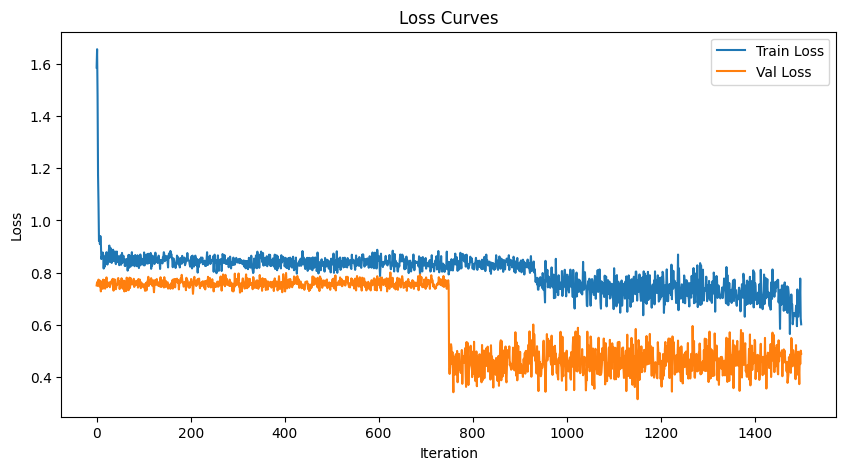

In [110]:
fig = plt.figure(facecolor="w", figsize=(10, 5))

# plot for a single epoch training and validation loss - num_steps=4, batches=40


# get train and val loss for 1 epoch
train_loss = history["train_loss"][:1500]
val_loss = history["val_loss"][:1500]

# print(len(train_loss), len(val_loss))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")

# draw a vertical line at the end of the first epoch
# plt.axvline(x=len(train_loss)//2, color="r", linestyle="--")



plt.title("Loss Curves")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [112]:
# checkpoint = torch.load(savepath, weights_only=False)
# best_model = BasicSNN().to(device)
# best_model.load_state_dict(checkpoint['model_state_dict'])

checkpoint = torch.load(savepath, weights_only=False)
best_model = BasicSNN(num_steps=4).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [113]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

# shuffle the data
test_data_sample = test_data_sample.sample(frac=1, random_state=42).reset_index(drop=True) 

test_dataset_sample = CustomDatasetSpike(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [114]:
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in tqdm(test_data_loader_sample, desc="Calculating Accuracy"):
            images, labels = images.to(device), labels.to(device)
            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]
            spk_mean = spk_rec.sum(dim=0)  # Sum spikes over time
            preds = spk_mean.argmax(dim=1)  # Get predictions

            # Append predictions and labels
            y_true = torch.cat((y_true, labels))
            y_pred = torch.cat((y_pred, preds))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        # Convert to numpy arrays only once
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

        # Compute overall accuracy
        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred

def calculate_accuracy(model, data_loader, device="cuda"):
    correct = 0
    total = 0

    for data, targets in tqdm(data_loader, desc="Calculating Accuracy"):
        data, targets = data.to(device), targets.to(device)

        utils.reset(model)  # Reset neuron states per batch

        spk_rec, _ = model(data)

        # calculate accuracy
        acc = SF.accuracy_rate(spk_rec, targets)
        # print(acc)

        correct += acc * data.size(0)
        total += data.size(0)

    return correct / total


y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device=device)
# Example usage
calculate_accuracy(best_model, test_data_loader_sample, device=device)

# y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_spike_sample, device=device)


Calculating Accuracy: 100%|██████████| 300/300 [00:20<00:00, 14.50it/s]


Accuracy: 0.9512


Calculating Accuracy: 100%|██████████| 300/300 [00:15<00:00, 19.90it/s]


np.float64(0.9511666666666667)

              precision    recall  f1-score   support

   Malicious       0.99      0.91      0.95      6000
      Benign       0.92      0.99      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



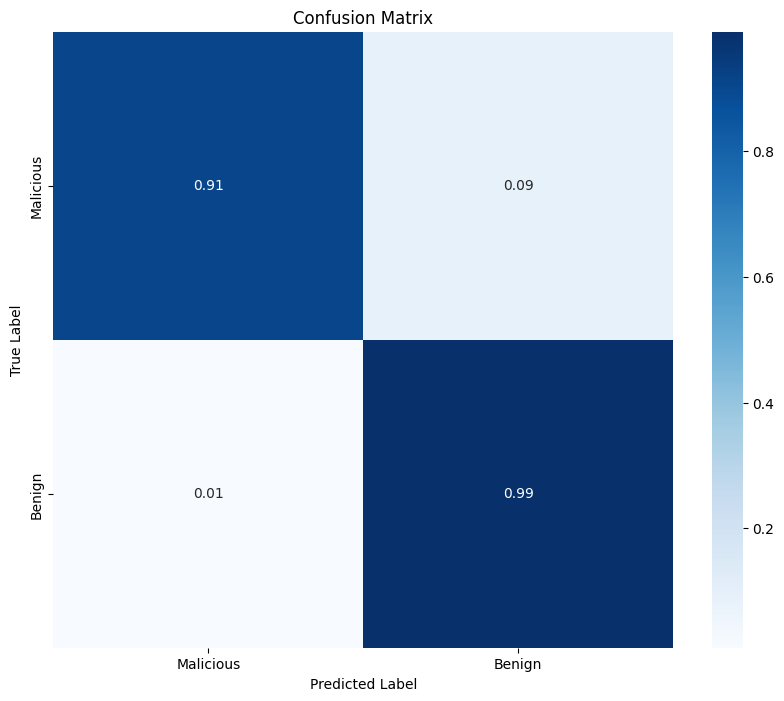

In [115]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    classification_rep = classification_report(y_true, y_pred, target_names=classes)
    print(classification_rep)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)), normalize='true' if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_, normalize=True)

In [ ]:
# create a popup notification when the notebook run is complete
import os
os.system("notify-send 'Notebook run complete'")
